## Завдання 1
Підготуйте дані для аналізу:
 - Використовуйте датасет про діабет із бібліотеки sklearn.datasets.load_diabetes.
 - Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 (параметр random_state=42).
 - Масштабуйте ознаки за допомогою StandardScaler.
 - Перевірте форму матриць навчальної та тестової вибірок.



In [1]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
print("Форма матриць після розділення та масштабування:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"y_train:        {y_train.shape}")
print(f"y_test:         {y_test.shape}")

Форма матриць після розділення та масштабування:
X_train_scaled: (353, 10)
X_test_scaled:  (89, 10)
y_train:        (353,)
y_test:         (89,)


## Завдання 2
Побудуйте модель MLP для регресії:
 - Архітектура мережі:
     - Вхідний шар — кількість нейронів дорівнює числу ознак.
     - Перший прихований шар — 64 нейрони, активація ReLU.
     - Другий прихований шар — 32 нейрони, активація ReLU.
     - Третій прихований шар — 16 нейронів, активація ReLU.
     - Вихідний шар — 1 нейрон без активації.
 - Функція втрат: MSELoss.
 - Оптимізатор: Adam з learning_rate = 0.001.
 - Кількість епох: 50.


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test.values if hasattr(y_test, 'values') else y_test, dtype=torch.float32).unsqueeze(1)

In [11]:
class DiabetesMLP(nn.Module):
    def __init__(self, input_dim):
        super(DiabetesMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        return self.network(x)
        
input_features = X_train_t.shape[1]
model = DiabetesMLP(input_dim=input_features)

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
epochs = 50

In [15]:
print("Початок навчання моделі")
for epoch in range(1, epochs + 1):
    model.train()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch == 1 or epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_t)
            test_loss = criterion(test_outputs, y_test_t)
        print(f"Епоха [{epoch:02d}/{epochs}] -> Train MSE: {loss.item():.2f} | Test MSE: {test_loss.item():.2f}")

print("\nНавчання завершено!")

Початок навчання моделі
Епоха [01/50] -> Train MSE: 28667.71 | Test MSE: 25521.88
Епоха [10/50] -> Train MSE: 27873.14 | Test MSE: 24756.72
Епоха [20/50] -> Train MSE: 26482.14 | Test MSE: 23426.44
Епоха [30/50] -> Train MSE: 24363.16 | Test MSE: 21415.28
Епоха [40/50] -> Train MSE: 21344.26 | Test MSE: 18576.86
Епоха [50/50] -> Train MSE: 17434.42 | Test MSE: 14949.27

Навчання завершено!


## Завдання 3
Додайте регуляризацію і порівняйте результати:
 - Використовуйте параметр weight_decay=1e-4 в оптимізаторі Adam для ввімкнення L2-регуляризації.
 - Проведіть два експерименти:
     - Без регуляризації.
     - З регуляризацією (L2).
 - Для кожної версії моделі обчисліть значення MAE і R² на тестовій вибірці.
 - Оформіть результати в таблиці:

| Конфігурація | MAE | R² |
| :--- | :--- | :--- |
| Без регуляризації | ... | ... |
| З регуляризацією (L2) | ... | ... |

In [24]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

def run_experiment(use_regularization=False):
    model = DiabetesMLP(input_dim=input_features)
    criterion = nn.MSELoss()
    
    if use_regularization:
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
    for epoch in range(50):
        model.train()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_t).numpy()
    y_true = y_test_t.numpy()
    mae = mean_absolute_error(y_true, test_predictions)
    r2 = r2_score(y_true, test_predictions)
    
    return mae, r2

In [25]:
mae_base, r2_base = run_experiment(use_regularization=False)

In [26]:
mae_reg, r2_reg = run_experiment(use_regularization=True)

In [27]:
results = pd.DataFrame({
    "Конфігурація": ["Без регуляризації", "З регуляризацією (L2)"],
    "MAE": [f"{mae_base:.4f}", f"{mae_reg:.4f}"],
    "R²": [f"{r2_base:.4f}", f"{r2_reg:.4f}"]
})
results

,Конфігурація,MAE,R²
0,Без регуляризації,143.0687,-3.8575
1,З регуляризацією (L2),143.2321,-3.8716


## Завдання 4
Проаналізуйте результати моделі:
 - Побудуйте scatter-графік, що порівнює реальні та передбачені значення цільової змінної:
     - По осі X — реальні значення (y_test).
     - По осі Y — передбачені значення (y_pred).
     - Додайте діагональ y = x для візуального порівняння.
 - Підпишіть осі та заголовок графіка.
 - Збережіть зображення під іменем diabetes_healthrisk_analysis.png.
 - Зробіть короткий аналітичний висновок:
     - Як впливає регуляризація на якість моделі?
     - Які ознаки, на вашу думку, найсильніше впливають на результат?


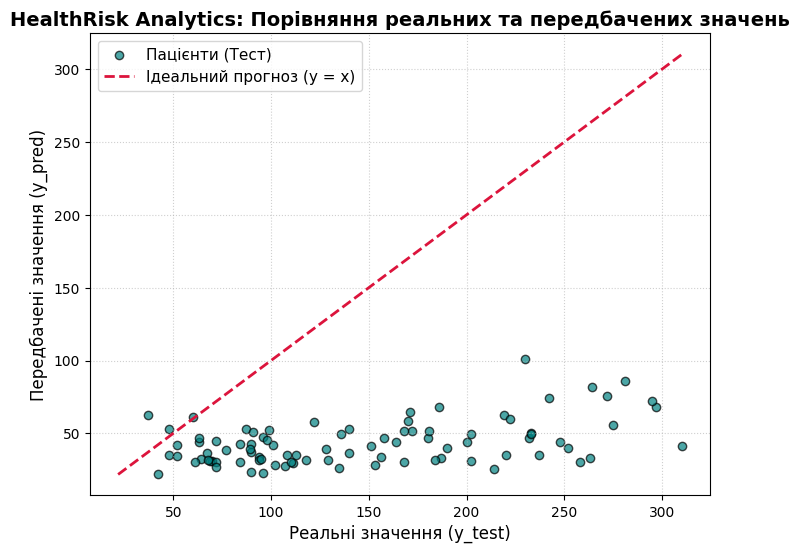

In [28]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy()
y_true = y_test_t.numpy()
plt.figure(figsize=(8, 6))

plt.scatter(y_true, y_pred, color='teal', alpha=0.7, edgecolors='k', label='Пацієнти (Тест)')

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Ідеальний прогноз (y = x)')

plt.xlabel('Реальні значення (y_test)', fontsize=12)
plt.ylabel('Передбачені значення (y_pred)', fontsize=12)
plt.title('HealthRisk Analytics: Порівняння реальних та передбачених значень', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.savefig('diabetes_healthrisk_analysis.png', dpi=300, bbox_inches='tight')

plt.show()